# EDA Dataset Videojuegos (Fase 2)

Este notebook desarrolla el Analisis Exploratorio de Datos (EDA) para el dataset de ventas de videojuegos, alineado con los requisitos de la Fase 2 del proyecto.

## 1. Librerias y configuracion

In [1]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 2. Carga y entendimiento inicial

In [2]:
df = pd.read_csv('../datasets/Video Games Sales (1980-2024) - Raw.csv')
print('Dimensiones:', df.shape)
df.head()

Dimensiones: (64016, 14)


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17-09-2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06-11-2015,14-01-2018


In [3]:
display(df.dtypes.to_frame('dtype'))
display(df.describe(include='all').T.head(10))

,dtype
img,str
title,str
console,str
genre,str
publisher,str
developer,str
critic_score,float64
total_sales,float64
na_sales,float64
jp_sales,float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
img,64016,56177,/games/boxart/default.jpg,7810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,64016,39798,Plants vs. Zombies,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
console,64016,81,PC,12617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,64016,20,Misc,9304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publisher,64016,3383,Unknown,8842,NaN,NaN,NaN,NaN,NaN,NaN,NaN
developer,63999,8862,Unknown,4435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
critic_score,6678.0,NaN,NaN,NaN,7.22044,1.457066,1.0,6.4,7.5,8.3,10.0
total_sales,18922.0,NaN,NaN,NaN,0.349113,0.807462,0.0,0.03,0.12,0.34,20.32
na_sales,12637.0,NaN,NaN,NaN,0.26474,0.494787,0.0,0.05,0.12,0.28,9.76
jp_sales,6726.0,NaN,NaN,NaN,0.102281,0.168811,0.0,0.02,0.04,0.12,2.13


## 3. Limpieza minima para EDA

In [4]:
# Copia de trabajo
df_eda = df.copy()

# Fecha y anio
df_eda['release_date'] = pd.to_datetime(df_eda['release_date'], format='%d-%m-%Y', errors='coerce')
df_eda['release_year'] = df_eda['release_date'].dt.year

# Columnas numericas para analisis
num_cols = ['critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_year']
for col in num_cols:
    df_eda[col] = pd.to_numeric(df_eda[col], errors='coerce')

print('Preparacion basica completada')

Preparacion basica completada


## 4. Valores faltantes

In [5]:
missing = df_eda.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_eda) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df

,missing_count,missing_pct
critic_score,57338,89.57
jp_sales,57290,89.49
na_sales,51379,80.26
pal_sales,51192,79.97
other_sales,48888,76.37
last_update,46137,72.07
total_sales,45094,70.44
release_date,7051,11.01
release_year,7051,11.01
developer,17,0.03


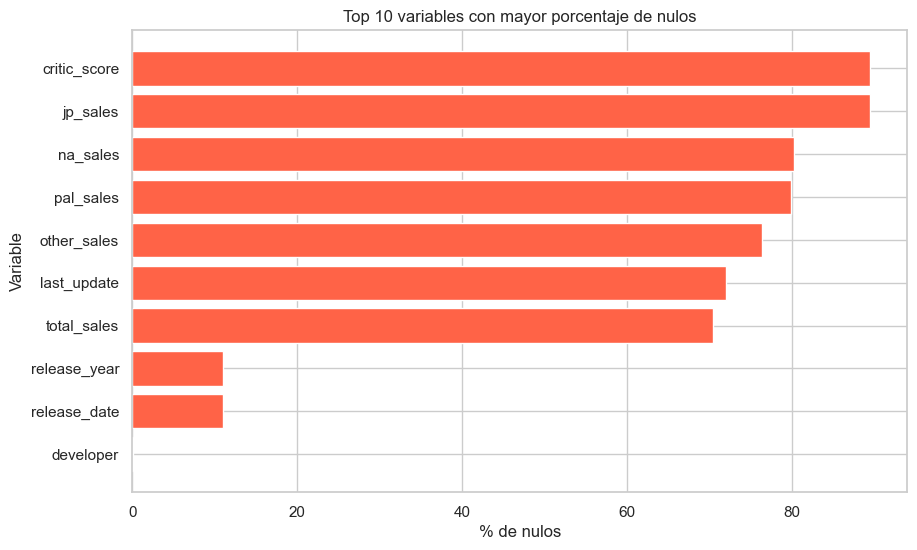

In [6]:
plt.figure(figsize=(10, 6))
top_missing = missing_df.head(10).sort_values('missing_pct', ascending=True)
plt.barh(top_missing.index, top_missing['missing_pct'], color='tomato')
plt.title('Top 10 variables con mayor porcentaje de nulos')
plt.xlabel('% de nulos')
plt.ylabel('Variable')
plt.show()

### Insight de faltantes

- Los nulos no son homogéneos: se concentran en variables de valor analítico alto (`critic_score` y ventas regionales).
- Para evitar sesgo, no conviene imputar con media global en esta etapa.
- En preprocesamiento, la prioridad será imputación segmentada y/o banderas de faltante.

### Estrategia propuesta de tratamiento de faltantes
- `critic_score`: no imputar media global directamente; analizar por genero/consola o usar modelos si fuera necesario.
- Ventas regionales (`na_sales`, `jp_sales`, `pal_sales`, `other_sales`): conservar nulos para no introducir sesgo; evaluar escenarios de imputacion especifica en preprocesamiento.
- `release_date` y `release_year`: usar `release_year` cuando exista y marcar faltantes para analisis temporal.
- `last_update`: baja relevancia para este EDA, puede excluirse en modelado si no aporta.

## 5. Deteccion de outliers (IQR y Z-score)

In [7]:
# IQR sobre total_sales y critic_score
def iqr_outliers(series):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (series < low) | (series > high)
    return int(mask.sum()), low, high

for col in ['total_sales', 'critic_score']:
    n_out, low, high = iqr_outliers(df_eda[col])
    print(f'{col}: outliers={n_out}, limite_inf={low:.2f}, limite_sup={high:.2f}')

total_sales: outliers=1963, limite_inf=-0.44, limite_sup=0.81
critic_score: outliers=148, limite_inf=3.55, limite_sup=11.15


In [8]:
# Z-score para total_sales
s = df_eda['total_sales'].dropna()
z = (s - s.mean()) / s.std(ddof=0)
z_outliers = (z.abs() > 3).sum()
print('Outliers por Z-score (|z|>3) en total_sales:', int(z_outliers))

Outliers por Z-score (|z|>3) en total_sales: 301


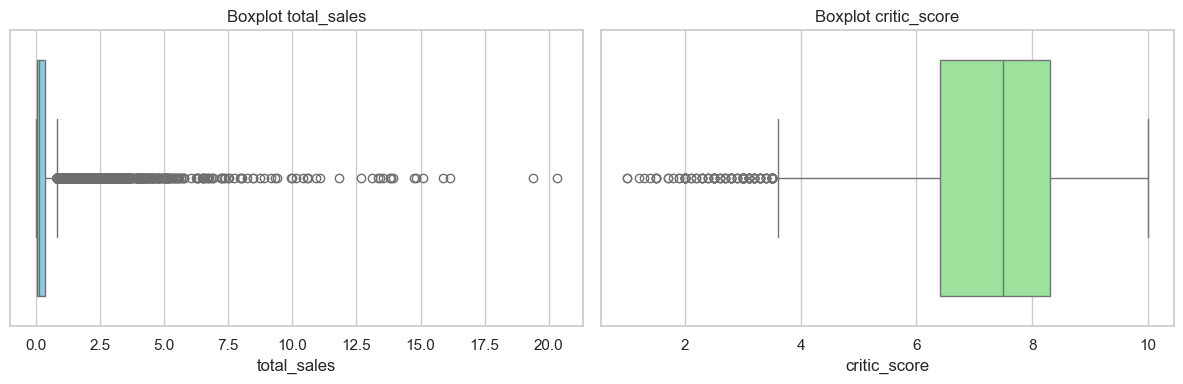

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_eda['total_sales'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot total_sales')

sns.boxplot(x=df_eda['critic_score'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot critic_score')
plt.tight_layout()
plt.show()

### Insight de outliers

- `total_sales` muestra cola larga y outliers esperables para títulos blockbuster.
- En `critic_score` los outliers son menos extremos y deben validarse antes de filtrado.
- Decisión sugerida: conservar outliers de negocio y aplicar tratamiento robusto solo en modelado.

## 6. Analisis de distribuciones (numericas)

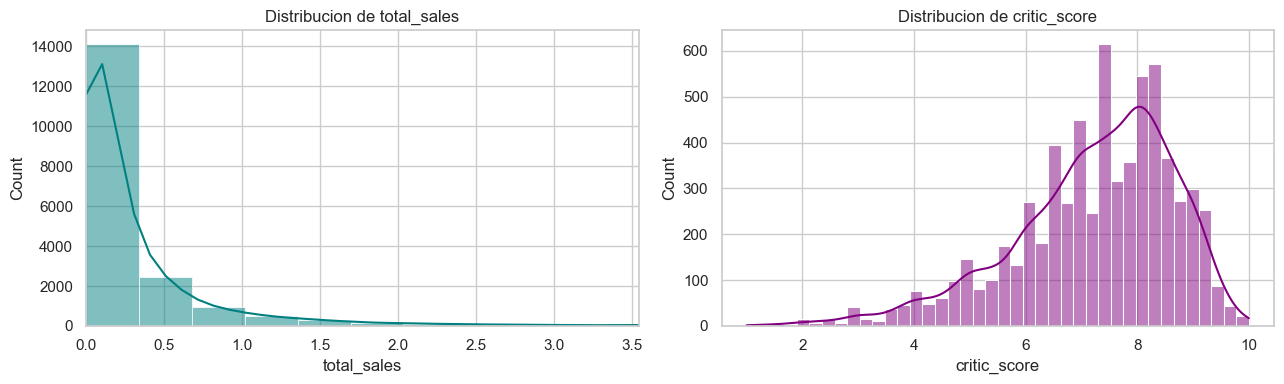

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df_eda['total_sales'].dropna(), bins=60, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribucion de total_sales')
axes[0].set_xlim(0, df_eda['total_sales'].quantile(0.99))

sns.histplot(df_eda['critic_score'].dropna(), bins=40, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Distribucion de critic_score')
plt.tight_layout()
plt.show()

In [11]:
print('Asimetria total_sales:', round(df_eda['total_sales'].dropna().skew(), 3))
print('Asimetria critic_score:', round(df_eda['critic_score'].dropna().skew(), 3))

Asimetria total_sales: 8.775
Asimetria critic_score: -0.911


### Insight de distribuciones

- `total_sales` está fuertemente sesgada a la derecha, por lo que media y desviación pueden ser poco representativas.
- `critic_score` tiene distribución más estable y útil como predictor complementario.
- Conviene reportar mediana y percentiles junto con media para evitar conclusiones sesgadas.

## 7. Analisis univariado

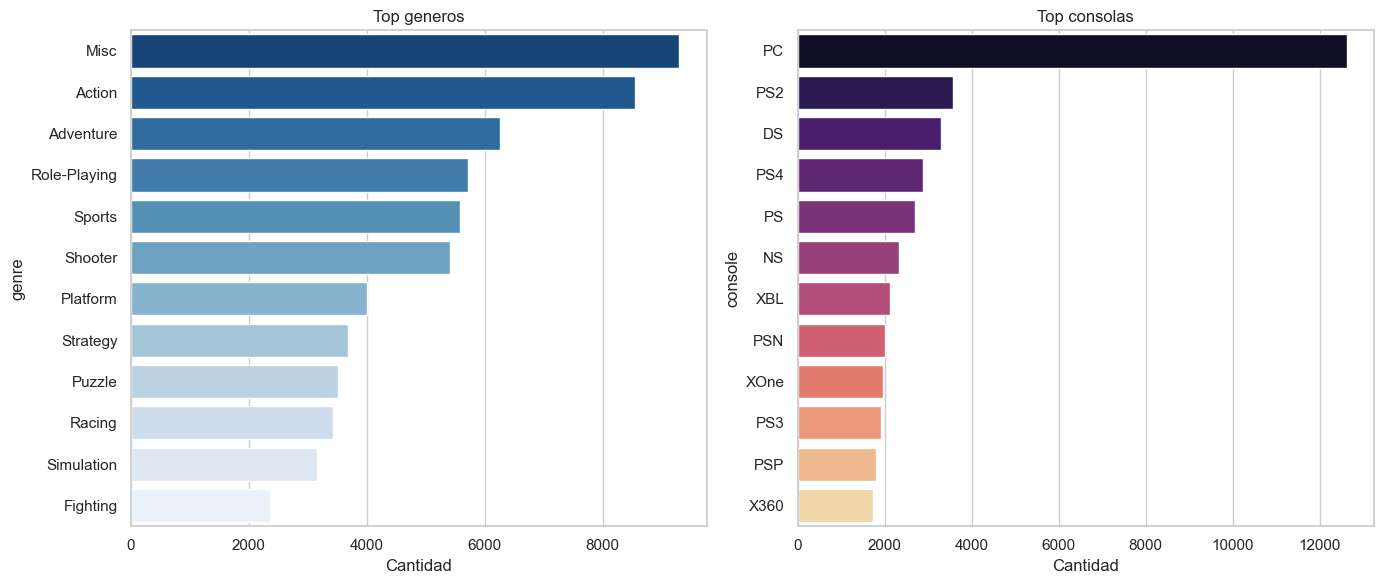

In [12]:
# Categóricas principales
top_genres = df_eda['genre'].value_counts().head(12)
top_consoles = df_eda['console'].value_counts().head(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top generos')
axes[0].set_xlabel('Cantidad')

sns.barplot(x=top_consoles.values, y=top_consoles.index, ax=axes[1], palette='magma')
axes[1].set_title('Top consolas')
axes[1].set_xlabel('Cantidad')
plt.tight_layout()
plt.show()

In [13]:
# Numericas
display(df_eda[['total_sales', 'critic_score', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']].describe().T)

,count,mean,std,min,25%,50%,75%,max
total_sales,18922.0,0.349113,0.807462,0.0,0.03,0.12,0.34,20.32
critic_score,6678.0,7.220440,1.457066,1.0,6.40,7.50,8.30,10.00
na_sales,12637.0,0.264740,0.494787,0.0,0.05,0.12,0.28,9.76
jp_sales,6726.0,0.102281,0.168811,0.0,0.02,0.04,0.12,2.13
pal_sales,12824.0,0.149472,0.392653,0.0,0.01,0.04,0.14,9.85
other_sales,15128.0,0.043041,0.126643,0.0,0.00,0.01,0.03,3.12


### Insight univariado

- La frecuencia por `genre` y `console` no es uniforme: hay concentración en pocos segmentos.
- Esta concentración sugiere riesgo de desbalance para tareas predictivas.
- Próximo paso recomendado: crear análisis estratificado por segmentos dominantes.

## 8. Analisis multivariado y relaciones

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_year
critic_score,1.000000,0.281166,0.300289,0.147448,0.246694,0.243847,0.021746
total_sales,0.281166,1.000000,0.914149,0.212469,0.907421,0.859329,-0.038600
na_sales,0.300289,0.914149,1.000000,0.065091,0.684517,0.687512,-0.049645
jp_sales,0.147448,0.212469,0.065091,1.000000,0.131796,0.082653,-0.375608
pal_sales,0.246694,0.907421,0.684517,0.131796,1.000000,0.817030,0.084919
other_sales,0.243847,0.859329,0.687512,0.082653,0.817030,1.000000,0.089620
release_year,0.021746,-0.038600,-0.049645,-0.375608,0.084919,0.089620,1.000000


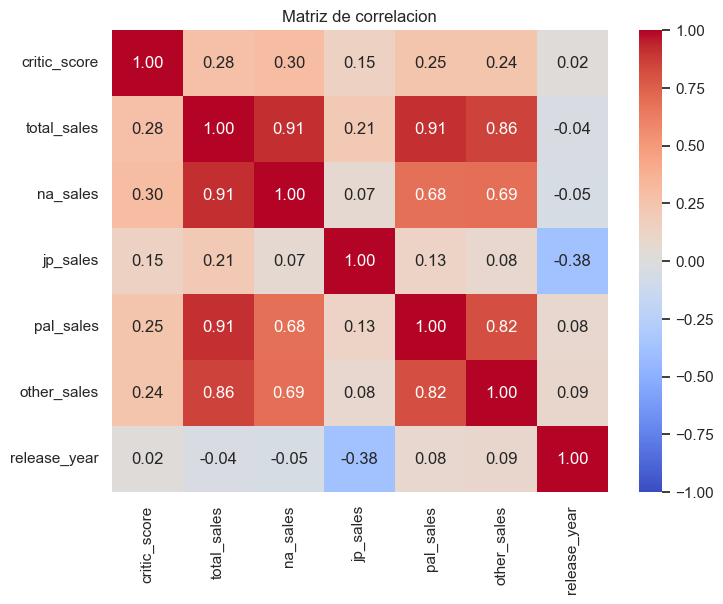

In [14]:
corr_cols = ['critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_year']
corr = df_eda[corr_cols].corr(numeric_only=True)
display(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de correlacion')
plt.show()

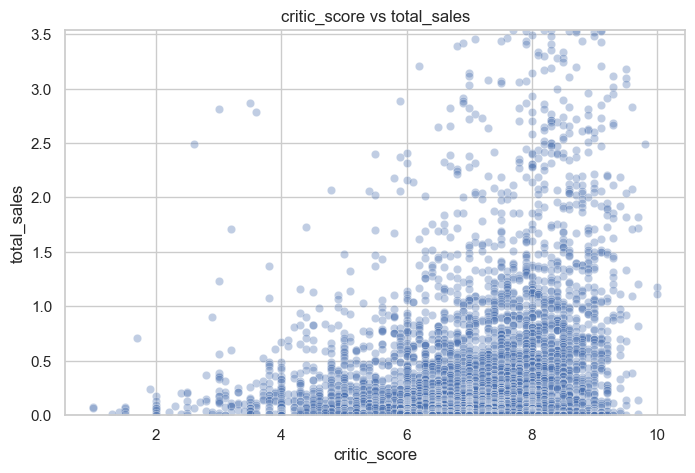

In [15]:
# Relacion score-ventas
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_eda, x='critic_score', y='total_sales', alpha=0.35)
plt.ylim(0, df_eda['total_sales'].quantile(0.99))
plt.title('critic_score vs total_sales')
plt.xlabel('critic_score')
plt.ylabel('total_sales')
plt.show()

console,PC,PS2,DS,PS4,PS,NS,XBL,PSN
genre,,,,,,,,
Misc,1375,493,853,152,436,60,374,195
Action,1279,443,369,531,233,400,362,269
Adventure,1839,521,409,289,241,235,43,143
Role-Playing,1287,281,259,371,212,289,125,209
Sports,576,561,197,159,396,106,84,127
Shooter,1192,245,53,262,173,145,400,260
Platform,472,138,123,153,97,201,165,150
Strategy,1629,118,123,90,218,89,103,110


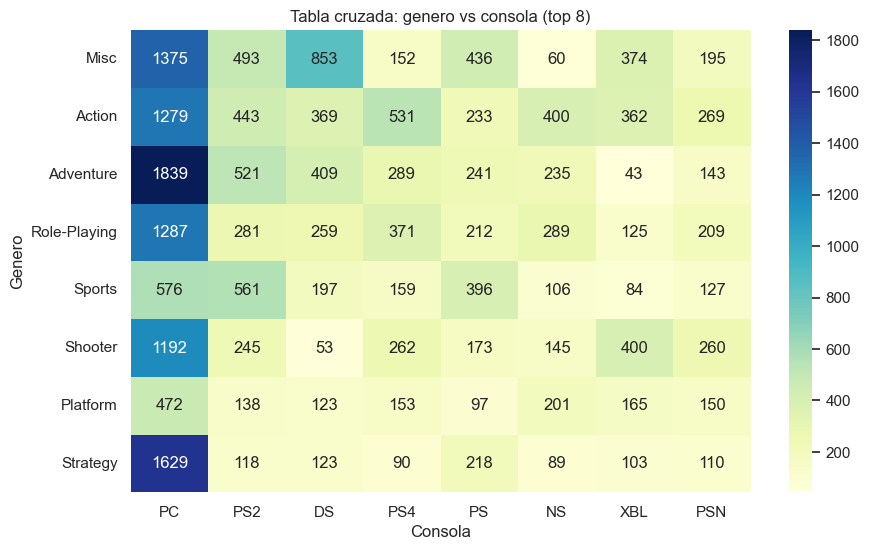

In [16]:
# Tabla cruzada genero vs consola (top)
top_g = df_eda['genre'].value_counts().head(8).index
top_c = df_eda['console'].value_counts().head(8).index
ct = pd.crosstab(df_eda['genre'], df_eda['console']).loc[top_g, top_c]
display(ct)

plt.figure(figsize=(10, 6))
sns.heatmap(ct, cmap='YlGnBu', annot=True, fmt='d')
plt.title('Tabla cruzada: genero vs consola (top 8)')
plt.xlabel('Consola')
plt.ylabel('Genero')
plt.show()

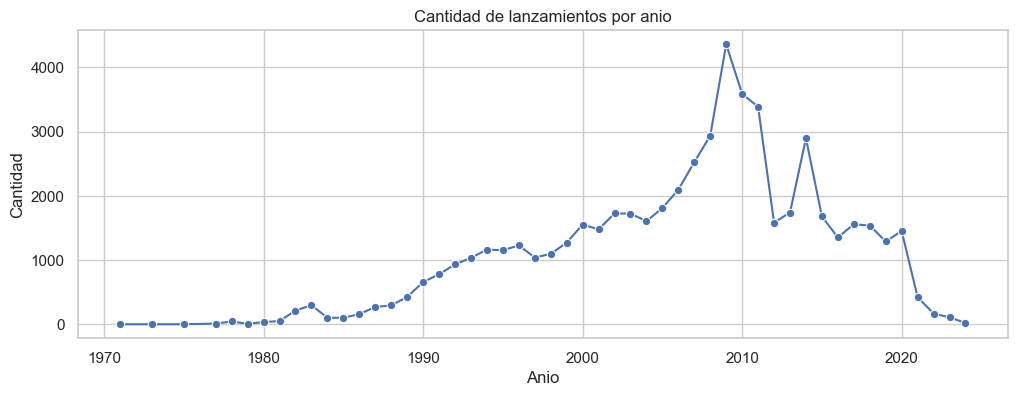

In [17]:
# Tendencia temporal de lanzamientos
games_per_year = df_eda['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
sns.lineplot(x=games_per_year.index, y=games_per_year.values, marker='o')
plt.title('Cantidad de lanzamientos por anio')
plt.xlabel('Anio')
plt.ylabel('Cantidad')
plt.show()

### Insight multivariado y temporal

- La correlación entre ventas regionales y `total_sales` valida consistencia estructural del dataset.
- La relación `critic_score`-`total_sales` es positiva, pero con dispersión alta.
- La serie temporal evidencia ciclos de mercado; el año debe tratarse como variable explicativa clave.

## 9. Hipotesis iniciales

1. A mayor `critic_score`, mayor `total_sales` en promedio.
2. La distribucion de ventas varía por genero y por consola.
3. Existen diferencias regionales claras entre `na_sales`, `jp_sales` y `pal_sales`.
4. La cantidad de lanzamientos por anio no es estable y presenta periodos de expansion/caida.
5. Los outliers de ventas representan titulos blockbuster y no necesariamente errores de captura.

## 10. Mapa de visualizaciones del EDA

Este bloque resume qué responde cada tipo de gráfico y dónde se usa en el análisis:

- Histogramas (`total_sales`, `critic_score`): forma de distribución y sesgo.
- Boxplots (`total_sales`, `critic_score`): detección visual de outliers.
- Barras (top de géneros y consolas): concentración por categorías principales.
- Dispersión (`critic_score` vs `total_sales`): dirección y fuerza de relación.
- Mapas de calor (correlaciones y tabla cruzada): dependencias entre variables.
- Serie temporal (`release_year`): evolución del volumen de lanzamientos.

## 11. Insights principales y cierre ejecutivo

1. El dataset tiene escala suficiente para detectar patrones de mercado por segmento.
2. La calidad del dato está condicionada por faltantes en `critic_score` y ventas regionales.
3. `total_sales` presenta alta asimetría positiva: pocos títulos concentran gran parte de ventas.
4. `critic_score` y `total_sales` muestran asociación positiva, pero no explican por sí solas todo el comportamiento.
5. Género, consola y año aportan segmentación clave para las siguientes etapas.
6. La serie temporal sugiere ciclos de expansión y desaceleración en la industria.